# Statistics for WLASL: Pre-processed

In [83]:
import json
from pathlib import Path
from typing import cast, List, TypedDict
import matplotlib.pyplot as plt
import numpy as np
#locals
from configs import WLASL_ROOT, SPLIT_DIR, CLASSES_PATH
from video_dataset import get_wlasl_info
import stats
import preprocess as preproc
from statistics import median, mean, median_high, median_low

## From the WLASL GitHUB page

Data Description
-----------------

* `gloss`: *str*, data file is structured/categorised based on sign gloss, or namely, labels.

* `bbox`: *[int]*, bounding box detected using YOLOv3 of (xmin, ymin, xmax, ymax) convention. Following OpenCV convention, (0, 0) is the up-left corner.

* `fps`: *int*, frame rate (=25) used to decode the video as in the paper.

* `frame_start`: *int*, the starting frame of the gloss in the video (decoding
with FPS=25), *indexed from 1*.

* `frame_end`: *int*, the ending frame of the gloss in the video (decoding with FPS=25). -1 indicates the gloss ends at the last frame of the video.

* `instance_id`: *int*, id of the instance in the same class/gloss.

* `signer_id`: *int*, id of the signer.

* `source`: *str*, a string identifier for the source site.

* `split`: *str*, indicates sample belongs to which subset.

* `url`: *str*, used for video downloading.

* `variation_id`: *int*, id for dialect (indexed from 0).

* `video_id`: *str*, a unique video identifier.


### Additional info:

* The videos come pre-cut from the original youtube videos, therefore, the video_id is essentially a unique identifier for each instance

* There are some issues with the labelling, especially where certain frame start and ends are way too high. However, some of these labels could be corrected by hand to falvage the data. Originally, i just set the start frame to 0 and the end frame to the last frame, however in the modified preprocessing script, i have added a flag to strictly remove these labels for the time being

* All precut video clips have a width and height of 256 pixels. 


### Naming convention:
For the naming of different functions, 'set' and 'split' can somtimes be used interchangibly to mean different things, which can be confusing. So for all code written by me,
* **SPLIT**: A split of WLASL, one of asl100, asl300, asl1000 and asl2000
* **SET**: A subset of a given wlasl split, one of train, val test


# TODO:
- make a flag to control preprocessed vs unprocessed
- add removed instances
- add bounding box info

## Split

#### Pick split

In [84]:
split_options: List[stats.AVAIL_SPLITS] = ["asl100", "asl300", "asl1000", "asl2000"]
print('Options:')
for i, split_name in enumerate(split_options):
    print(f'{i} : {split_name}')

Options:
0 : asl100
1 : asl300
2 : asl1000
3 : asl2000


In [85]:
split_idx = 0 #change for different split
split_name: stats.AVAIL_SPLITS = split_options.pop(split_idx)
print(f'Selected: {split_name}')

Selected: asl100


In [86]:
labels_dir = Path('./preprocessed/labels_new') #NOTE: needs to be changed at some point 
split_dir = labels_dir / split_name

with open(CLASSES_PATH, 'r') as f:
    classes = json.load(f)

In [87]:
unprocessed_split_dir = Path(WLASL_ROOT) / SPLIT_DIR
with open(unprocessed_split_dir / f'{split_name}.json', 'r') as f:
    unproc_split = json.load(f)


## Set

In [88]:
set_options: List[stats.AVAIL_SETS] = ['train', 'test', 'val']
print('Options:')
for i, set_name in enumerate(set_options):
    print(f'{i} : {set_name}')

Options:
0 : train
1 : test
2 : val


#### Pick set

In [89]:
set_idx = 0
set_name: stats.AVAIL_SETS = set_options.pop(set_idx)
print(f'Selected: {set_name}')

Selected: train


Unprocessed

In [90]:
cast(List[stats.wlasl_class_dict], unproc_split)
unproc_seperated = stats.seperate_by_set(unproc_split)
unproc_set = unproc_seperated[set_name]
# print(seperated.keys())
subset_size = sum([len(glossd['instances']) for glossd in unproc_set])
print(f'Unprocessed set info for {split_name}/{set_name}')
print(f"Num instances: {subset_size}")

Unprocessed set info for asl100/train
Num instances: 1442


In [91]:
ex_sample = unproc_set[0]
print(f'gloss: {ex_sample["gloss"]}')
print(f'Num instances: {len(ex_sample["instances"])}')

gloss: book
Num instances: 30


Preprocessed

In [92]:
set_info = stats.retrieve_split_data(split=split_name, labels_dir=labels_dir, pattern=f'{set_name}_instances*.json')
removed_info = stats.retrieve_split_data(split=split_name, labels_dir=labels_dir, pattern=f'*{set_name}.json')

print(f'Set info for {split_name}/{set_name}')
for cnt, (key, value) in enumerate(set_info.items()):
    assert cnt != 1, 'Too many entries found'
    print(f'File path: {key}')
    preproc_set = cast(List[preproc.InstanceDict], value)
    print(f'Num instances: {len(preproc_set)}\n')

print('Removed samples:')
err_dict = preproc.ErrDict({'policy':'strict', 'num_offenders': 0, 'instances': []})
for key, value in removed_info.items():
    print(f'File path: {key}')
    incoming_err_dict = cast(preproc.ErrDict, value)
    assert incoming_err_dict['policy'] == err_dict['policy']
    err_dict['num_offenders'] += incoming_err_dict['num_offenders']
    err_dict['instances'].extend(incoming_err_dict['instances'])
assert err_dict['num_offenders'] == len(err_dict['instances'])
print(f'policy: {err_dict["policy"]}')
print(f'Total removed: {err_dict["num_offenders"]}')

Set info for asl100/train
File path: train_instances_fixed_frange_bboxes_len.json
Num instances: 1408

Removed samples:
File path: strict_bad_frame_ranges_train.json
policy: strict
Total removed: 34


In [93]:
preproc_set = stats.reverse_preproc_format(preproc_instances=preproc_set)
ex_sample = preproc_set[0]
print(f'gloss: {ex_sample["gloss"]}')
print(f'Num instances: {len(ex_sample["instances"])}')

gloss: book
Num instances: 29


Choose processed or unprocessed:

In [94]:
# current_set = unproc_set
current_set = preproc_set


## Stats

In [ ]:
figsize = (8, 5)
bins = None

#### Example

In [96]:
ex_idx = 0
ex_gloss = current_set[ex_idx]
print(f"Gloss label: {ex_gloss['gloss']}")

Gloss label: book


In [97]:
ex_gloss_stats = stats.collect_class_stats(ex_gloss['instances'])
print('Available keys: ')
for key in ex_gloss_stats:
    print(f'- {key}')

Available keys: 
- num_instances
- length_distribution
- signers_distribution
- source_distribution
- url_distribution
- variation_distribution


Number of videos:

In [98]:
print(f"Num instances: {ex_gloss_stats['num_instances']}")

Num instances: 29


Length distribution: 

24


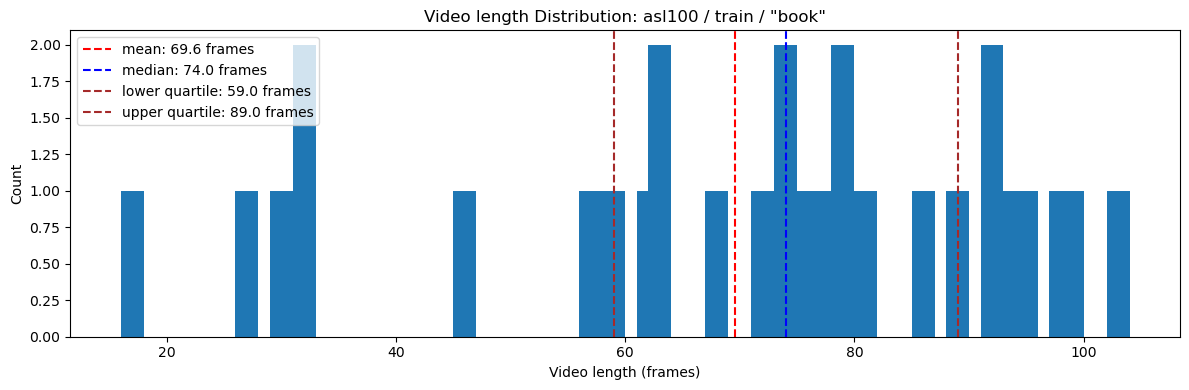

In [ ]:
histogram = ex_gloss_stats['length_distribution']
print(len(histogram))
stats.plot_distribution(
    histogram,
    gloss=ex_gloss['gloss'],
    set_name=set_name,
    split_name=split_name,
    metric='Video length',
    unit='frames',
    categorical=False,
    figsize=figsize,
    bins=bins
)

2


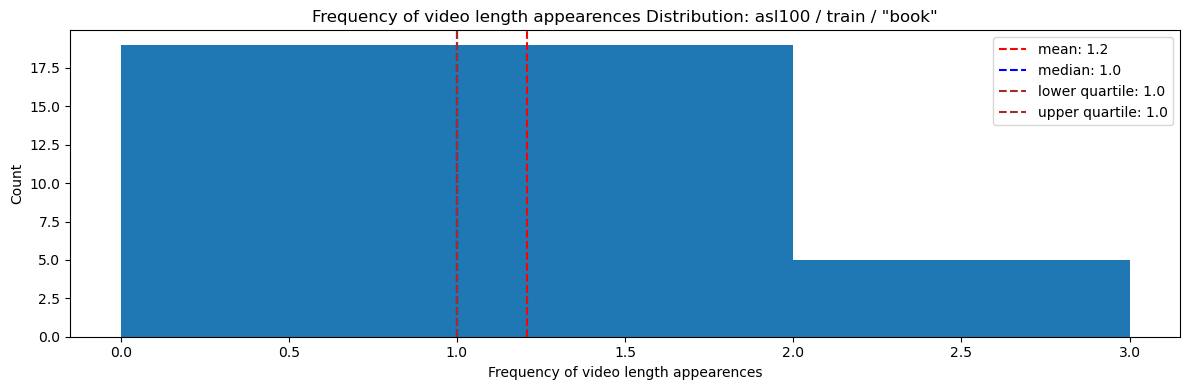

In [ ]:
count_frequencies = stats.make_histogram(histogram.values())
print(len(count_frequencies))
stats.plot_distribution(    
    count_frequencies,
    gloss=ex_gloss['gloss'],
    set_name=set_name,
    split_name=split_name,
    metric='Frequency of video length appearences',
    categorical=False,
    figsize=figsize,
    bins=bins
)

Signers Distribution

13


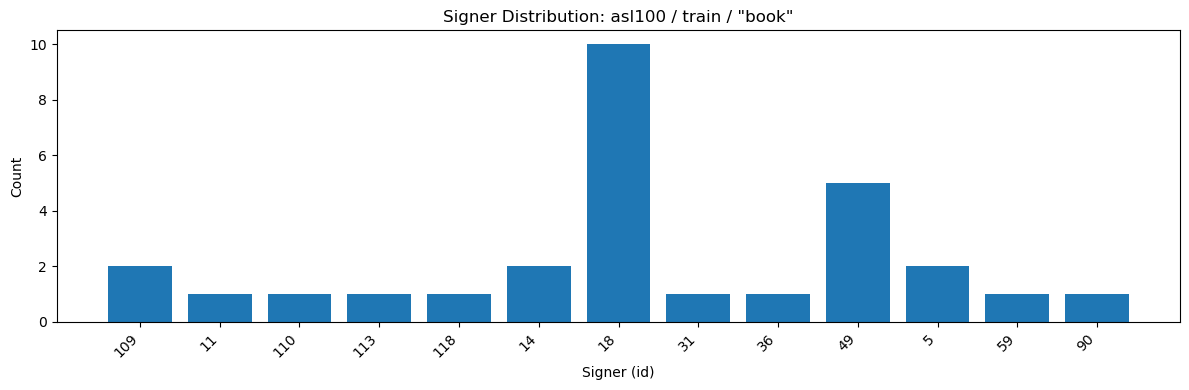

In [ ]:
histogram = ex_gloss_stats['signers_distribution']
print(len(histogram))
stats.plot_distribution(
    histogram,
    gloss=ex_gloss['gloss'],
    set_name=set_name,
    split_name=split_name,
    metric='Signer',
    unit='id',
    categorical=True,
    figsize=figsize,
    bins=bins
)

4


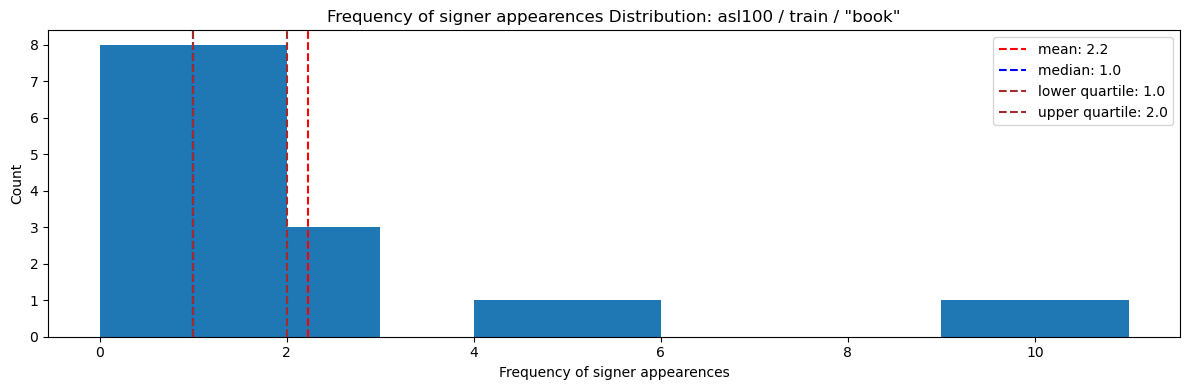

In [ ]:
count_frequencies = stats.make_histogram(histogram.values())
print(len(count_frequencies))
stats.plot_distribution(
    count_frequencies,
    gloss=ex_gloss['gloss'],
    set_name=set_name,
    split_name=split_name,
    metric='Frequency of signer appearences',
    categorical=False,
    figsize=figsize,
    bins=bins
)

Source distribution

12


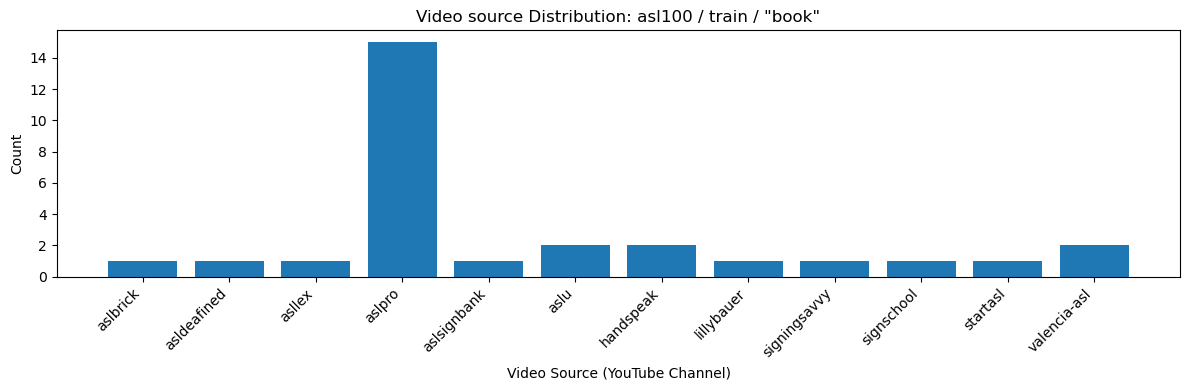

In [ ]:
histogram = ex_gloss_stats['source_distribution']
print(len(histogram))
stats.plot_distribution(
    histogram,
    gloss=ex_gloss['gloss'],
    set_name=set_name,
    split_name=split_name,
    metric='Video Source',
    unit='YouTube Channel',
    categorical=True,
    figsize=figsize,
    bins=bins
)

3


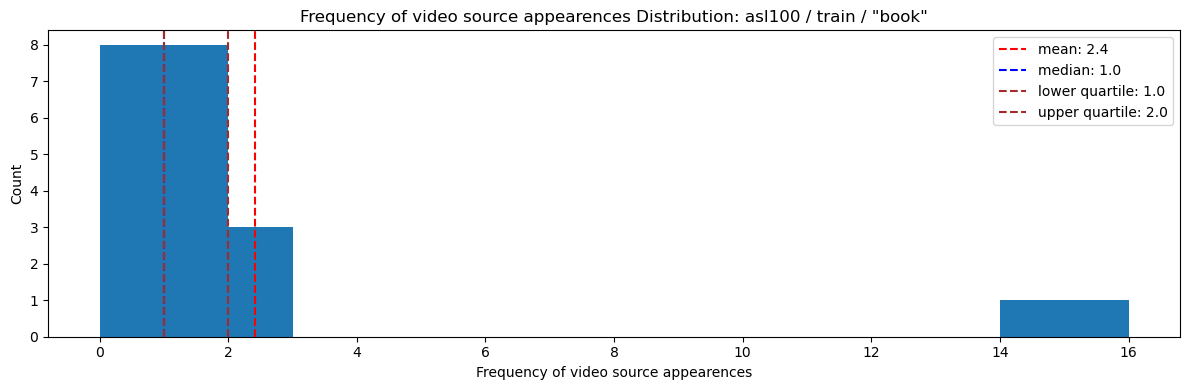

In [ ]:
count_frequencies = stats.make_histogram(histogram.values())
print(len(count_frequencies))
stats.plot_distribution(
    count_frequencies,
    gloss=ex_gloss['gloss'],
    set_name=set_name,
    split_name=split_name,
    metric='Frequency of video source appearences',
    categorical=False,
    figsize=figsize,
    bins=bins
)

URL distribution

In [105]:
histogram = ex_gloss_stats['url_distribution']
print(len(histogram))
# stats.plot_distribution(
#     histogram,
#     gloss=ex_gloss['gloss'],
#     set_name=set_name,
#     split_name=split_name,
#     metric='Video',
#     unit='URL',
#     categorical=True
# )

29


In [106]:
count_frequencies = stats.make_histogram(histogram.values())
print(len(count_frequencies))

# stats.plot_distribution(
#     count_frequencies,
#     gloss=ex_gloss['gloss'],
#     set_name=set_name,
#     split_name=split_name,
#     metric='Frequency of video url appearences',
#     categorical=False
# )

1
